Project paths ready
Figure Generation for Paper [Figure 5]: t-SNE Visualisation (4-industry)
Background coloring: ACTUAL XGBoost predictions, not a 2D KNN approximation
Data loaded successfully.

Representative case selected per industry:
  G46 (Wholesale Trade): Company ID 57347
  G47 (Retail Trade): Company ID 59369
  L68 (Real Estate): Company ID 35400
  F42 (Construction): Company ID 14454

Background model predictions computed directly (no 2D approximation).
Predicted bankrupt: 1931 / 4140

Running shared t-SNE embedding...

[Figure 5] saved: results\figures\figure5_tsne_visualization_4industry.png


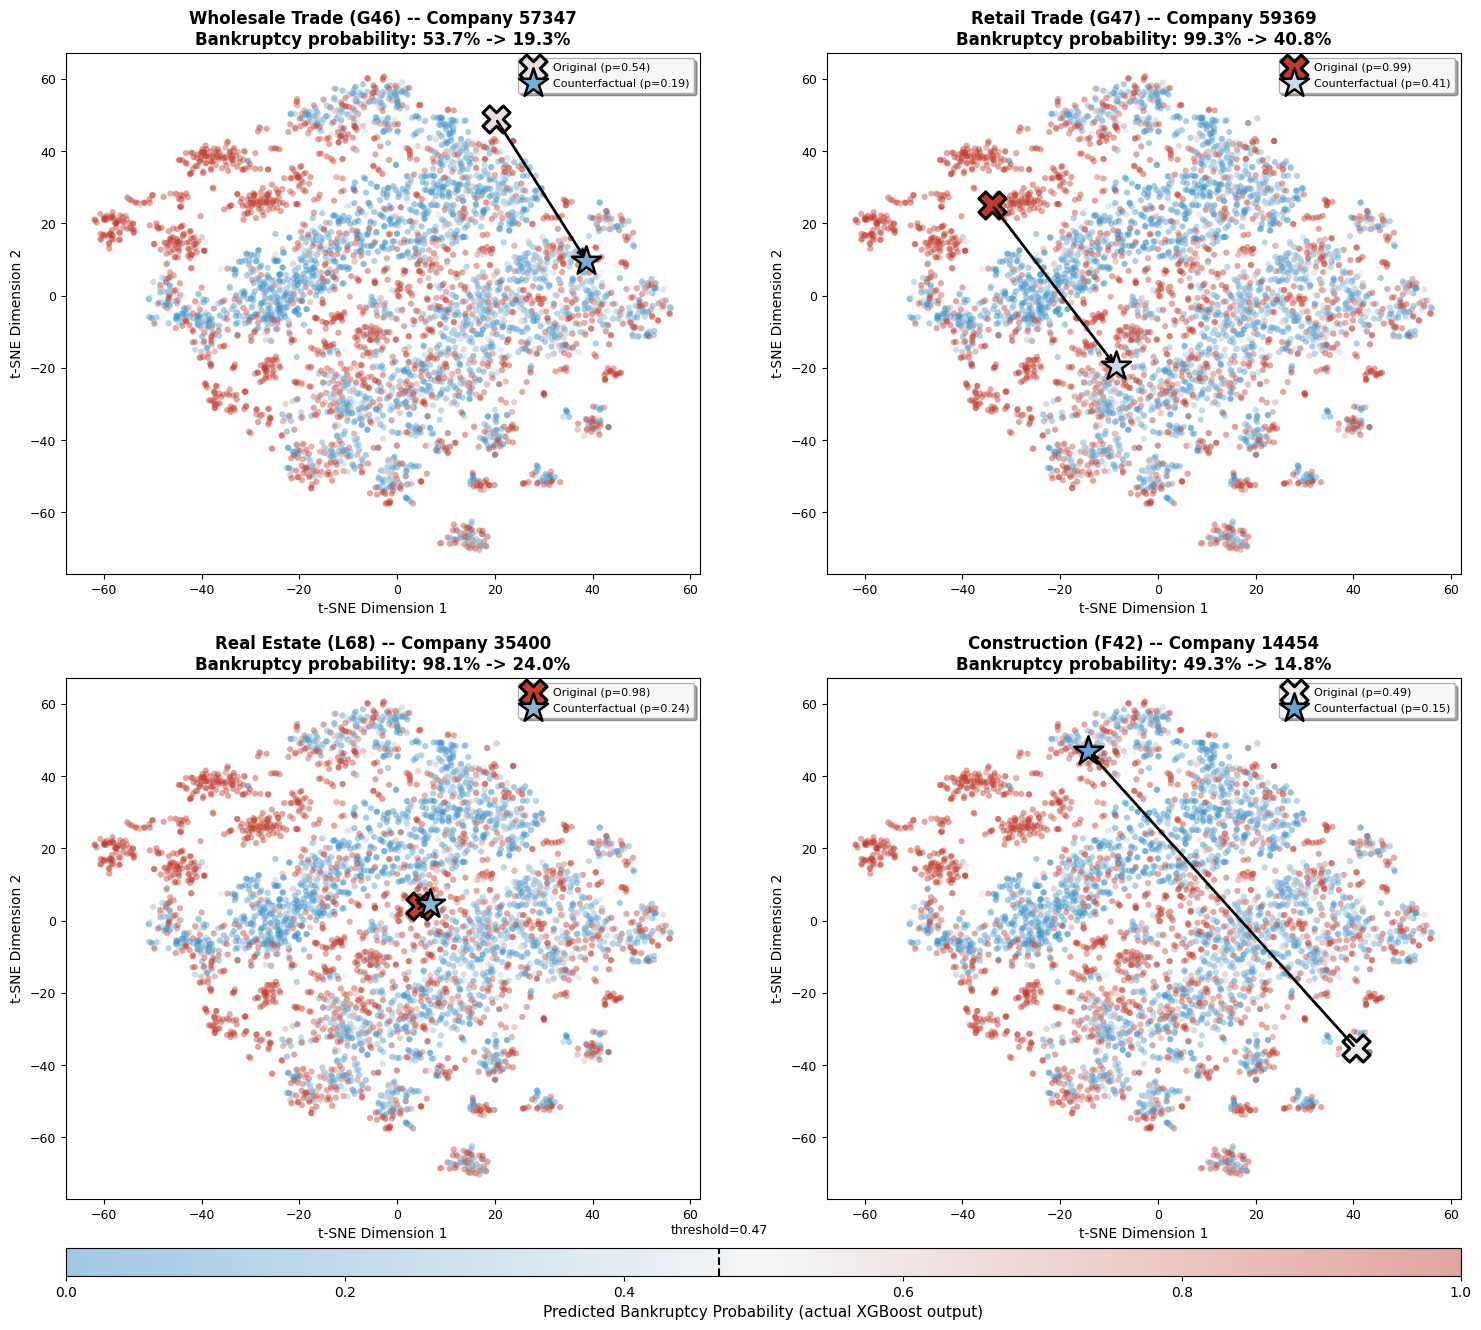


[Sanity Check] Actual model probabilities for each representative case:
  G46: Original p=0.5370 -> CF p=0.1926 (threshold=0.4683)
  G47: Original p=0.9929 -> CF p=0.4082 (threshold=0.4683)
  L68: Original p=0.9811 -> CF p=0.2400 (threshold=0.4683)
  F42: Original p=0.4925 -> CF p=0.1482 (threshold=0.4683)


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings('ignore')

# ============================================================================
# Project paths
# ============================================================================
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
MODEL_DIR = RESULTS_DIR / 'model'
FIGURE_DIR = RESULTS_DIR / 'figures'

for d in [FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project paths ready")

print("=" * 80)
print("Figure Generation for Paper [Figure 5]: t-SNE Visualisation (4-industry)")
print("Background coloring: ACTUAL XGBoost predictions, not a 2D KNN approximation")
print("=" * 80)

# ============================================================================
# 1. Data Loading
# ============================================================================
df_train = pd.read_csv(DATA_DIR / 'resampled_data_final_full.csv')
features = joblib.load(MODEL_DIR / 'selected_features_final_full.pkl')
cf_results = pd.read_csv(DATA_DIR / 'cf_results_filtered_4industry.csv')
agent3_results = pd.read_csv(DATA_DIR / 'agent3_ensemble_results_4industry.csv')
model = joblib.load(MODEL_DIR / 'base_model_final_full.pkl')
threshold = joblib.load(MODEL_DIR / 'base_model_threshold_final_full.pkl')
print("Data loaded successfully.")

# ============================================================================
# 2. Select representative case per industry (unchanged logic)
# ============================================================================
TARGET_SIC_CODES = ['G46', 'G47', 'L68', 'F42']
SIC_LABELS = {'G46': 'Wholesale Trade', 'G47': 'Retail Trade', 'L68': 'Real Estate', 'F42': 'Construction'}

pass_firms = agent3_results[agent3_results['decision'] == 'Pass']

representative_cases = {}
for sic in TARGET_SIC_CODES:
    sector_pass = pass_firms[pass_firms['SIC_CD_3'] == sic]
    if sector_pass.empty:
        sector_pass = agent3_results[agent3_results['SIC_CD_3'] == sic]
    if sector_pass.empty:
        continue
    best_row = sector_pass.loc[sector_pass['final_score'].idxmax()]
    representative_cases[sic] = int(best_row['company_id'])

print("\nRepresentative case selected per industry:")
for sic, cid in representative_cases.items():
    print(f"  {sic} ({SIC_LABELS[sic]}): Company ID {cid}")

# ============================================================================
# 3. KEY CHANGE — compute each background point's ACTUAL model probability
#    BEFORE t-SNE, in the original 62-dimensional space. This is what will
#    color the scatter, instead of a KNN boundary fit on the 2D projection.
# ============================================================================
X = df_train[features]
y = df_train['PERF_12M']

background_probs = model.predict_proba(X)[:, 1]  # true XGBoost bankruptcy probability
background_predicted_class = (background_probs >= threshold).astype(int)

print(f"\nBackground model predictions computed directly (no 2D approximation).")
print(f"Predicted bankrupt: {background_predicted_class.sum()} / {len(background_predicted_class)}")

# ============================================================================
# 4. Shared t-SNE fit (unchanged: one embedding for all 4 industries + targets)
# ============================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

target_vectors = []
target_meta = []
target_probs = []  # actual model probability for original and CF points

for sic, company_id in representative_cases.items():
    target_row = cf_results[cf_results['ID'] == company_id]
    if target_row.empty:
        continue
    target_row = target_row.iloc[0]

    original_vec = np.array([target_row[f'Original_{f}'] for f in features])
    cf_vec = np.array([target_row[f'CF_{f}'] for f in features])

    target_vectors.append(original_vec)
    target_meta.append({'sic': sic, 'company_id': company_id, 'type': 'original'})
    target_probs.append(model.predict_proba(original_vec.reshape(1, -1))[0, 1])

    target_vectors.append(cf_vec)
    target_meta.append({'sic': sic, 'company_id': company_id, 'type': 'cf'})
    target_probs.append(model.predict_proba(cf_vec.reshape(1, -1))[0, 1])

target_vectors = np.array(target_vectors)
target_scaled = scaler.transform(target_vectors)

X_combined = np.vstack([X_scaled, target_scaled])
n_background = len(X_scaled)

print("\nRunning shared t-SNE embedding...")
tsne = TSNE(
    n_components=2, random_state=42, perplexity=30,
    n_iter=1000, init='pca', learning_rate='auto'
)
X_tsne = tsne.fit_transform(X_combined)

tsne_background = X_tsne[:n_background]
tsne_targets = X_tsne[n_background:]

# ============================================================================
# 5. Plot — background points colored by ACTUAL predicted probability
#    (continuous colormap: blue = low risk, red = high risk), no KNN region
#    fill and no synthetic decision-boundary contour. The threshold itself
#    is instead marked via point EDGE color (crossed threshold = bold outline),
#    so the visualization communicates the real model output, not a 2D proxy.
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

# Diverging colormap: blue (low prob) -> white (near threshold) -> red (high prob)
risk_cmap = LinearSegmentedColormap.from_list(
    'risk', ['#2E86C1', '#EAECEE', '#C0392B'], N=256
)

for ax_idx, sic in enumerate(TARGET_SIC_CODES):
    if sic not in representative_cases:
        axes[ax_idx].axis('off')
        continue

    ax = axes[ax_idx]
    company_id = representative_cases[sic]

    orig_idx = next(i for i, m in enumerate(target_meta) if m['sic'] == sic and m['type'] == 'original')
    cf_idx = next(i for i, m in enumerate(target_meta) if m['sic'] == sic and m['type'] == 'cf')
    tsne_orig = tsne_targets[orig_idx]
    tsne_cf = tsne_targets[cf_idx]
    orig_prob = target_probs[orig_idx]
    cf_prob = target_probs[cf_idx]

    # Background: color = actual model probability (continuous), not a
    # binary KNN-approximated region
    sc = ax.scatter(tsne_background[:, 0], tsne_background[:, 1],
                     c=background_probs, cmap=risk_cmap, vmin=0, vmax=1,
                     alpha=0.45, s=20, edgecolors='none', zorder=3)

    # Original and CF points, also colored by their TRUE probability, but
    # with distinct markers/sizes so they remain identifiable against the
    # continuous background
    ax.scatter(tsne_orig[0], tsne_orig[1], c=[orig_prob], cmap=risk_cmap, vmin=0, vmax=1,
               s=380, marker='X', label=f'Original (p={orig_prob:.2f})',
               zorder=10, edgecolors='black', linewidths=2.2)
    ax.scatter(tsne_cf[0], tsne_cf[1], c=[cf_prob], cmap=risk_cmap, vmin=0, vmax=1,
               s=480, marker='*', label=f'Counterfactual (p={cf_prob:.2f})',
               zorder=10, edgecolors='black', linewidths=1.8)

    ax.annotate('', xy=(tsne_cf[0], tsne_cf[1]), xytext=(tsne_orig[0], tsne_orig[1]),
                arrowprops=dict(arrowstyle='->', color='black', lw=2.0, connectionstyle='arc3,rad=0.0'),
                zorder=11)

    ax.set_title(f"{SIC_LABELS[sic]} ({sic}) -- Company {company_id}\n"
                 f"Bankruptcy probability: {orig_prob:.1%} -> {cf_prob:.1%}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1', fontsize=10)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.legend(loc='upper right', fontsize=8, frameon=True, framealpha=0.92, shadow=True, edgecolor='#AAAAAA')

# Shared colorbar for the whole figure
cbar = fig.colorbar(sc, ax=axes, orientation='horizontal', fraction=0.03, pad=0.04, aspect=50)
cbar.set_label('Predicted Bankruptcy Probability (actual XGBoost output)', fontsize=11)
cbar.ax.axvline(x=threshold, color='black', linewidth=1.5, linestyle='--')
cbar.ax.text(threshold, 1.5, f'threshold={threshold:.2f}', ha='center', fontsize=9)

plt.savefig(FIGURE_DIR / 'figure5_tsne_visualization_4industry.png', dpi=300, bbox_inches='tight')
print(f"\n[Figure 5] saved: {(FIGURE_DIR / 'figure5_tsne_visualization_4industry.png').relative_to(PROJECT_ROOT)}")
plt.show()

# ============================================================================
# 6. Sanity report — actual probabilities for each representative case
# ============================================================================
print("\n[Sanity Check] Actual model probabilities for each representative case:")
for sic in TARGET_SIC_CODES:
    if sic not in representative_cases:
        continue
    orig_idx = next(i for i, m in enumerate(target_meta) if m['sic'] == sic and m['type'] == 'original')
    cf_idx = next(i for i, m in enumerate(target_meta) if m['sic'] == sic and m['type'] == 'cf')
    print(f"  {sic}: Original p={target_probs[orig_idx]:.4f} -> CF p={target_probs[cf_idx]:.4f} "
          f"(threshold={threshold:.4f})")